##import libraries

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


##Load Data

In [ ]:
data=sns.load_dataset('titanic')
print(data)
print(data.to_string())
data_backup = data.copy()

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_male deck  embark_town alive  alo

##information

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
data.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
data.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

##Data Cleaning

In [ ]:
data.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
# drop column deck -> has over nulls
data=data.drop('deck',axis=1)
data.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

In [ ]:
# 2 nulls for embarked -> fill with mode
mode=data['embarked'].mode()
data['embarked']=data['embarked'].fillna(mode[0])
data['embarked']


,embarked
0,S
1,C
2,S
3,S
4,S
...,...
886,S
887,S
888,S
889,C


In [ ]:
# 2 nulls for embarked_town ->fill with mode
mode=data['embark_town'].mode()
data['embark_town']=data['embark_town'].fillna(mode[0])
data['embark_town']


,embark_town
0,Southampton
1,Cherbourg
2,Southampton
3,Southampton
4,Southampton
...,...
886,Southampton
887,Southampton
888,Southampton
889,Cherbourg


In [ ]:
# fill age for null
mean_age=data['age'].mean()
mean_age=int(mean_age)
data['age']=data['age'].fillna(mean_age)
data['age']

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,29.0
889,26.0


In [ ]:
data.isnull().sum()
# data cleaned!

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


##EDA

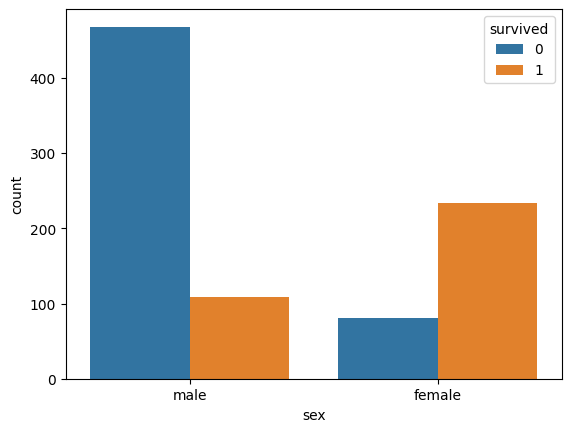

In [ ]:
#Relationship between the number of females and males that survived
# print(type(plt)) --> <class 'module'>

sns.countplot(x='sex', data=data, hue='survived')
plt.show()

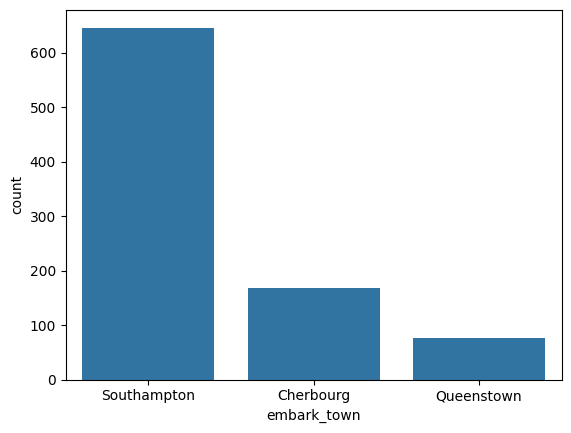

In [ ]:
# number of people for each town
sns.countplot(x='embark_town', data=data)
plt.show()

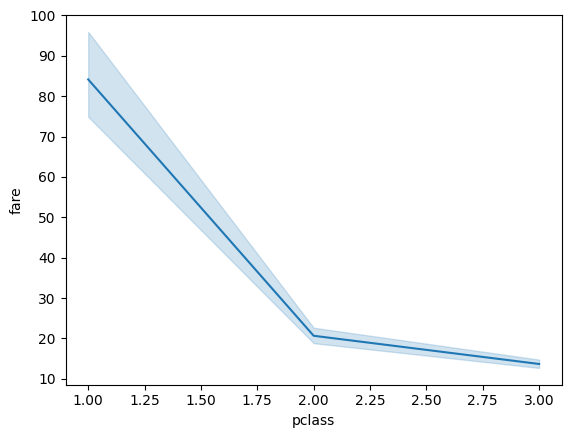

In [ ]:
from numpy._core.defchararray import index
#relation between Classes and fare
sns.lineplot(data=data,x='pclass',y='fare')
plt.yticks([10,20,30,40,50,60,70,80,90,100])
plt.show()

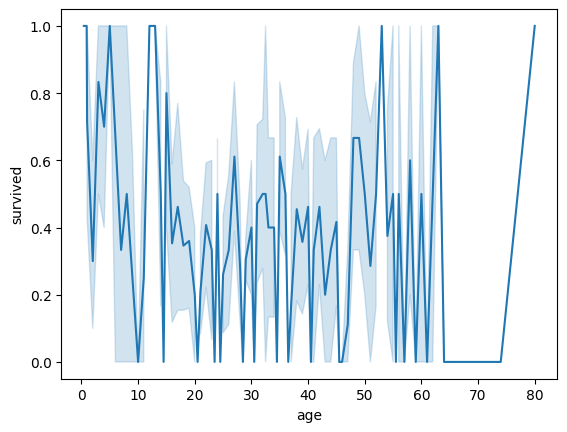

In [ ]:
#relation between survived people and their age
sns.lineplot(data=data,x='age',y='survived')
plt.show()


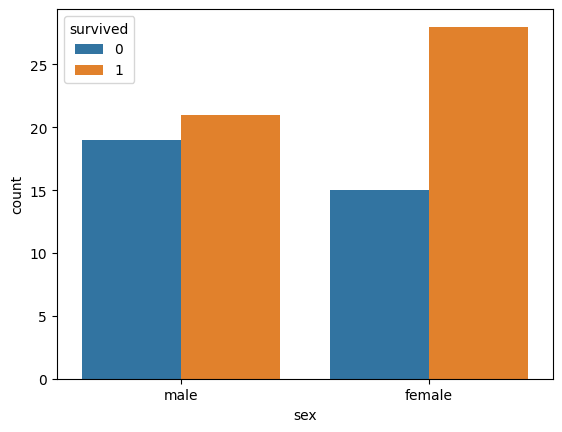

In [ ]:
# number of female children and male children survived
child_data = data[data['who'] == 'child']

sns.countplot(data=child_data, x='sex', hue='survived')
plt.show()

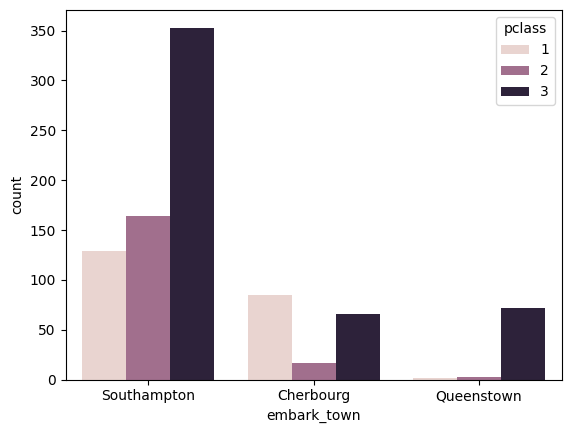

In [ ]:
#nNumber of people in every class from each town
sns.countplot(x='embark_town', hue='pclass', data=data)
plt.show()


##Feature engineering

In [ ]:
#family
family_size=data['sibsp']+data['parch']+1
data['family_size']=family_size
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True,1
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True,1
888,0,3,female,29.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False,4
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True,1


In [ ]:
#who is adult woman?
adult_female=(data['sex']=='female') & (data['who']=='woman')
data['adult_female']=adult_female
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size,adult_female
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,2,True
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2,True
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True,1,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True,1,True
888,0,3,female,29.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False,4,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True,1,False
